In [1]:
# Preparing the environment for EDA 
import pandas as pd
import numpy as np

print("Notebook is working!")


Notebook is working!


## Data Loading and Understanding

In [2]:
#Import Libraries and Datasets for EDA
import pandas as pd
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
price= pd.read_csv("../data/raw/sell_prices.csv")

In [3]:
# Viewing the first few rows of the sales dataset
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
# Viewing the first few rows of the calendar dataset
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [5]:
# Viewing the first few rows of the price dataset
price.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
# Viewing the size of the datasets
print("Sales shape:", sales.shape)
print("Calendar shape:", calendar.shape)
print("Prices shape:", price.shape)

Sales shape: (30490, 1919)
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)


Checking for Missing values

In [7]:
sales.isnull().sum().sum()

np.int64(0)

In [8]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [9]:
price.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [10]:
# Checking the columns of the sales dataset
sales.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object', length=1919)

In [11]:
sales.shape

(30490, 1919)

In [12]:

sales.columns[1:10]


Index(['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2',
       'd_3', 'd_4'],
      dtype='object')

In [13]:
# Converting the sales dataset from wide to long format
sales_long = sales.melt(
    id_vars=["id","item_id","dept_id","cat_id","store_id","state_id"],
    var_name="day",
    value_name="sales"
)
sales_long.head()


,id,item_id,dept_id,cat_id,store_id,state_id,day,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [14]:
sales_long.shape

(58327370, 8)

In [15]:
# Sampling the data for faster EDA
sales_sample = sales_long.sample(n=1000000, random_state=42)
sales_sample.head()

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales
47561074,FOODS_3_548_WI_2_validation,FOODS_3_548,FOODS_3,FOODS,WI_2,WI,d_1560,0
27190388,FOODS_3_231_WI_1_validation,FOODS_3_231,FOODS_3,FOODS,WI_1,WI,d_892,6
33395191,FOODS_3_319_CA_3_validation,FOODS_3_319,FOODS_3,FOODS,CA_3,CA,d_1096,31
41582921,HOUSEHOLD_1_098_WI_2_validation,HOUSEHOLD_1_098,HOUSEHOLD_1,HOUSEHOLD,WI_2,WI,d_1364,0
50528035,HOBBIES_1_008_CA_3_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_3,CA,d_1658,0


In [16]:
sales_sample.shape

(1000000, 8)

In [17]:
# Merging the sales sample with the calendar dataset to get date information
sales_sample = sales_sample.merge(
    calendar[["d","date","weekday","month","year"]],
    left_on="day",
    right_on="d",
    how="left"
)
sales_sample.head()

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,d,date,weekday,month,year
0,FOODS_3_548_WI_2_validation,FOODS_3_548,FOODS_3,FOODS,WI_2,WI,d_1560,0,d_1560,2015-05-07,Thursday,5,2015
1,FOODS_3_231_WI_1_validation,FOODS_3_231,FOODS_3,FOODS,WI_1,WI,d_892,6,d_892,2013-07-08,Monday,7,2013
2,FOODS_3_319_CA_3_validation,FOODS_3_319,FOODS_3,FOODS,CA_3,CA,d_1096,31,d_1096,2014-01-28,Tuesday,1,2014
3,HOUSEHOLD_1_098_WI_2_validation,HOUSEHOLD_1_098,HOUSEHOLD_1,HOUSEHOLD,WI_2,WI,d_1364,0,d_1364,2014-10-23,Thursday,10,2014
4,HOBBIES_1_008_CA_3_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_3,CA,d_1658,0,d_1658,2015-08-13,Thursday,8,2015


## Visualizing Patterns in Trends in Our Data

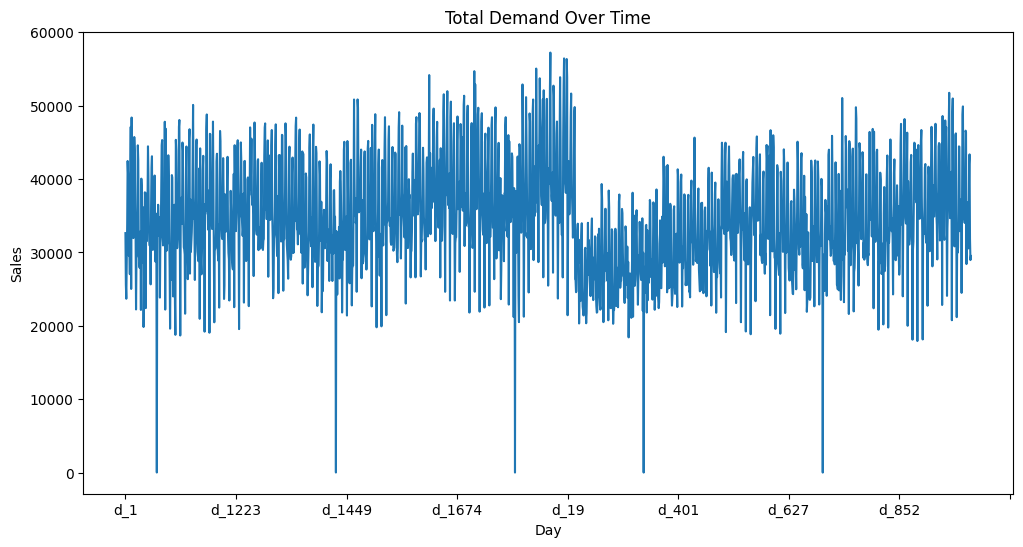

In [18]:
import matplotlib.pyplot as plt

# Aggregate total sales per day
daily_sales = sales_long.groupby("day")["sales"].sum()

# Plot
plt.figure(figsize=(12,6))
daily_sales.plot()

plt.title("Total Demand Over Time")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [19]:
# Merge daily sales with calendar to get real dates
daily_sales = sales_long.groupby("day")["sales"].sum().reset_index()

daily_sales = daily_sales.merge(
    calendar[["d", "date"]],
    left_on="day",
    right_on="d",
    how="left"
)

# Convert to datetime
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales.head()

,day,sales,d,date
0,d_1,32631,d_1,2011-01-29
1,d_10,25572,d_10,2011-02-07
2,d_100,23688,d_100,2011-05-08
3,d_1000,29260,d_1000,2013-10-24
4,d_1001,33877,d_1001,2013-10-25


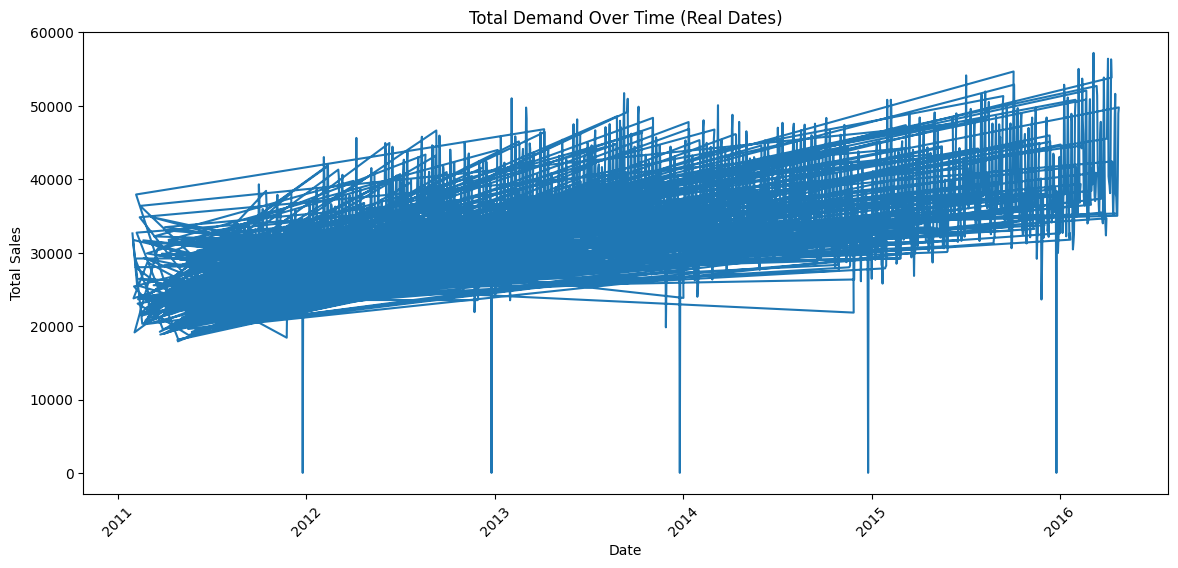

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Total Demand Over Time (Real Dates)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

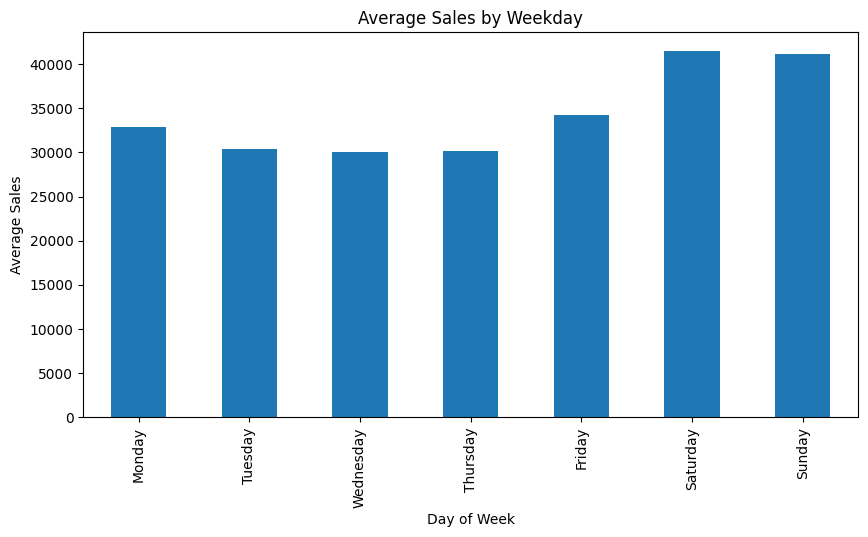

In [21]:
# Extract weekday
daily_sales["weekday"] = daily_sales["date"].dt.day_name()

# Aggregate by weekday
weekday_sales = daily_sales.groupby("weekday")["sales"].mean()

# Order days properly
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_sales = weekday_sales.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()

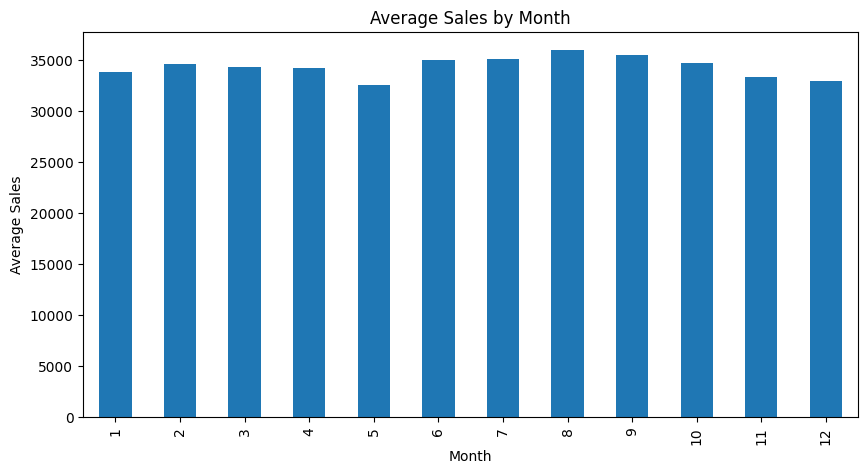

In [22]:
# Extract month
daily_sales["month"] = daily_sales["date"].dt.month

# Aggregate by month
monthly_sales = daily_sales.groupby("month")["sales"].mean()

# Plot
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

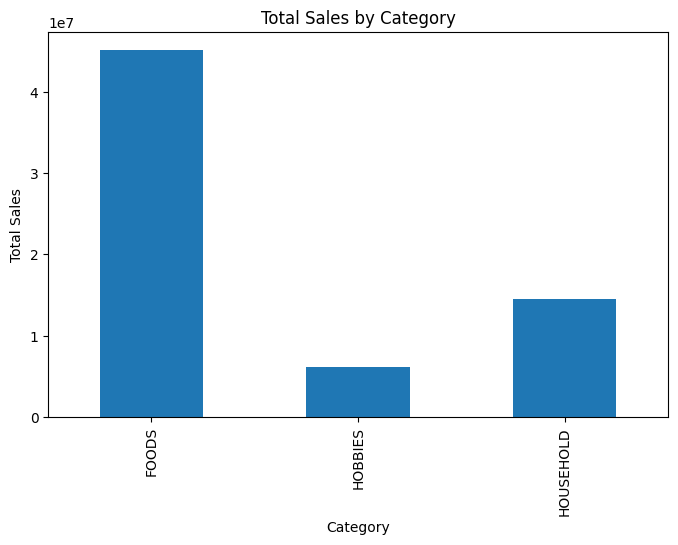

In [23]:
# Aggregate by category
category_sales = sales_long.groupby("cat_id")["sales"].sum()

# Plot
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

##Summary Statistics

In [24]:
sales_sample["sales"].describe()

count    1000000.000000
mean           1.120972
std            3.786222
min            0.000000
25%            0.000000
50%            0.000000
75%            1.000000
max          380.000000
Name: sales, dtype: float64

Distribution of Sales

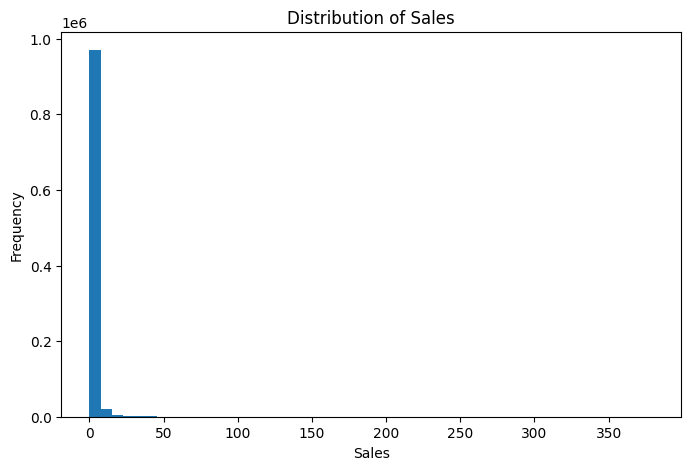

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(sales_sample["sales"], bins=50)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Outlier Detection (Boxplot)

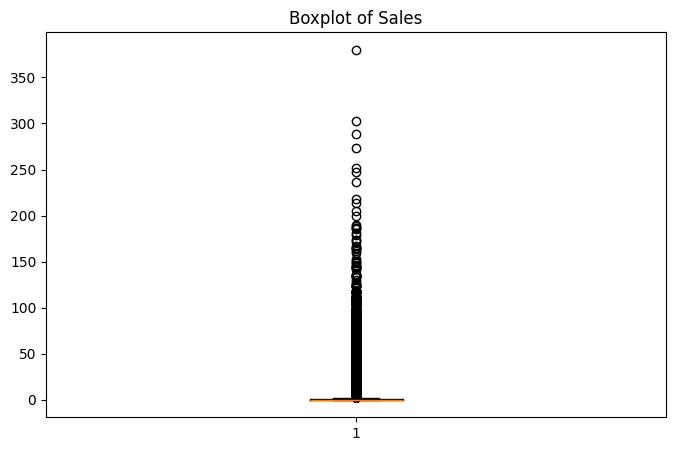

In [27]:
plt.figure(figsize=(8,5))
plt.boxplot(sales_sample["sales"], vert=True)

plt.title("Boxplot of Sales")

plt.show()